In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")

PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA device: Tesla T4


# CSV FÁJLOK ELLENŐRZÉSE

In [2]:
import pandas as pd
import os

base_path = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'

# Ellenőrizzük a CSV-ket
print("="*60)
print("CSV FÁJLOK ELLENŐRZÉSE")
print("="*60)

# Train CSV
train_csv_path = '/kaggle/input/140k-real-and-fake-faces/train.csv'
if os.path.exists(train_csv_path):
    train_df = pd.read_csv(train_csv_path)
    print(f"\n✓ train.csv found!")
    print(f"  Shape: {train_df.shape}")
    print(f"  Columns: {list(train_df.columns)}")
    print(f"\n  First 5 rows:")
    print(train_df.head())
else:
    print("\n✗ train.csv NOT found")

# Valid CSV
valid_csv_path = '/kaggle/input/140k-real-and-fake-faces/valid.csv'
if os.path.exists(valid_csv_path):
    valid_df = pd.read_csv(valid_csv_path)
    print(f"\n✓ valid.csv found!")
    print(f"  Shape: {valid_df.shape}")
else:
    print("\n✗ valid.csv NOT found")

# Test CSV
test_csv_path = '/kaggle/input/140k-real-and-fake-faces/test.csv'
if os.path.exists(test_csv_path):
    test_df = pd.read_csv(test_csv_path)
    print(f"\n✓ test.csv found!")
    print(f"  Shape: {test_df.shape}")
else:
    print("\n✗ test.csv NOT found")


CSV FÁJLOK ELLENŐRZÉSE

✓ train.csv found!
  Shape: (100000, 6)
  Columns: ['Unnamed: 0', 'original_path', 'id', 'label', 'label_str', 'path']

  First 5 rows:
   Unnamed: 0                                      original_path     id  \
0           0  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  31355   
1           1  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  02884   
2           2  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  33988   
3           3  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  53875   
4           4  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  24149   

   label label_str                  path  
0      1      real  train/real/31355.jpg  
1      1      real  train/real/02884.jpg  
2      1      real  train/real/33988.jpg  
3      1      real  train/real/53875.jpg  
4      1      real  train/real/24149.jpg  

✓ valid.csv found!
  Shape: (20000, 6)

✓ test.csv found!
  Shape: (20000, 6)


# MAPPÁK ELLENŐRZÉSE

In [3]:
# Számoljuk meg a képeket mappánként
for split in ['train', 'test', 'valid']:
    split_path = os.path.join(base_path, split)
    
    real_path = os.path.join(split_path, 'real')
    fake_path = os.path.join(split_path, 'fake')
    
    if os.path.exists(real_path) and os.path.exists(fake_path):
        real_count = len([f for f in os.listdir(real_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
        fake_count = len([f for f in os.listdir(fake_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
        
        print(f"\n{split.upper()}:")
        print(f"  Real: {real_count:,}")
        print(f"  Fake: {fake_count:,}")
        print(f"  Total: {real_count + fake_count:,}")

print("\n" + "="*60)


TRAIN:
  Real: 50,000
  Fake: 50,000
  Total: 100,000

TEST:
  Real: 10,000
  Fake: 10,000
  Total: 20,000

VALID:
  Real: 10,000
  Fake: 10,000
  Total: 20,000



# Adatok betöltése

In [4]:

import pandas as pd
from sklearn.utils import shuffle

# CSV-k betöltése
base_path = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'  # ← Ez a helyes!

train_df = pd.read_csv('/kaggle/input/140k-real-and-fake-faces/train.csv')
valid_df = pd.read_csv('/kaggle/input/140k-real-and-fake-faces/valid.csv')
test_df = pd.read_csv('/kaggle/input/140k-real-and-fake-faces/test.csv')

print("="*60)
print("ADATOK BETÖLTVE")
print("="*60)
print(f"Train: {len(train_df):,} kép")
print(f"Valid: {len(valid_df):,} kép")
print(f"Test:  {len(test_df):,} kép")

#Label distribution ellenőrzése
print(f"\nTrain - Real: {(train_df['label']==1).sum():,}, Fake: {(train_df['label']==0).sum():,}")
print(f"Valid - Real: {(valid_df['label']==1).sum():,}, Fake: {(valid_df['label']==0).sum():,}")
print(f"Test  - Real: {(test_df['label']==1).sum():,}, Fake: {(test_df['label']==0).sum():,}")

ADATOK BETÖLTVE
Train: 100,000 kép
Valid: 20,000 kép
Test:  20,000 kép

Train - Real: 50,000, Fake: 50,000
Valid - Real: 10,000, Fake: 10,000
Test  - Real: 10,000, Fake: 10,000


In [5]:
#Path-ok összeállítása (CSV-ben relatív path van)
train_df['full_path'] = train_df['path'].apply(lambda x: os.path.join(base_path, x))
valid_df['full_path'] = valid_df['path'].apply(lambda x: os.path.join(base_path, x))
test_df['full_path'] = test_df['path'].apply(lambda x: os.path.join(base_path, x))

# Path-ok összeállítása
train_df['full_path'] = train_df['path'].apply(lambda x: os.path.join(base_path, x))
valid_df['full_path'] = valid_df['path'].apply(lambda x: os.path.join(base_path, x))
test_df['full_path'] = test_df['path'].apply(lambda x: os.path.join(base_path, x))

print('Path ellenőrzés (első 5 train kép)')

for idx in range(5):
    path = train_df['full_path'].iloc[idx]
    exists = os.path.exists(path)
    label = train_df['label'].iloc[idx]
    print(f"{idx+1}. {'Nice' if exists else 'notnice'} {label} ({train_df['label_str'].iloc[idx]}) - {path}")

print("\n" + "="*60)
print("PATH ELLENŐRZÉS (első 10 train kép)")
print("="*60)
for idx in range(10):
    path = train_df['full_path'].iloc[idx]
    exists = os.path.exists(path)
    label = train_df['label'].iloc[idx]
    status = '✓' if exists else '✗'
    print(f"{idx+1}. {status} Label:{label} ({train_df['label_str'].iloc[idx]})")
    if not exists and idx < 3:
        print(f"   Path: {path}")

Path ellenőrzés (első 5 train kép)
1. Nice 1 (real) - /kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real/31355.jpg
2. Nice 1 (real) - /kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real/02884.jpg
3. Nice 1 (real) - /kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real/33988.jpg
4. Nice 1 (real) - /kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real/53875.jpg
5. Nice 1 (real) - /kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real/24149.jpg

PATH ELLENŐRZÉS (első 10 train kép)
1. ✓ Label:1 (real)
2. ✓ Label:1 (real)
3. ✓ Label:1 (real)
4. ✓ Label:1 (real)
5. ✓ Label:1 (real)
6. ✓ Label:1 (real)
7. ✓ Label:1 (real)
8. ✓ Label:1 (real)
9. ✓ Label:1 (real)
10. ✓ Label:1 (real)


In [6]:
# Listák készítése a Dataset osztályhoz
train_paths = train_df['full_path'].tolist()
train_labels = train_df['label'].tolist()

valid_paths = valid_df['full_path'].tolist()
valid_labels = valid_df['label'].tolist()

test_paths = test_df['full_path'].tolist()
test_labels = test_df['label'].tolist()

# Label konverzió: 1=real, 0=fake → 0=real, 1=fake (STANDARD)
train_labels = [1-label for label in train_labels]  
valid_labels = [1-label for label in valid_labels]
test_labels = [1-label for label in test_labels]

print("\n" + "="*60)
print("LABEL KONVERZIÓ (0=real, 1=fake)")
print("="*60)
print(f"Train - Real (0): {train_labels.count(0):,}, Fake (1): {train_labels.count(1):,}")
print(f"Valid - Real (0): {valid_labels.count(0):,}, Fake (1): {valid_labels.count(1):,}")

print("\n✓ Adatok betöltve és előkészítve!")


LABEL KONVERZIÓ (0=real, 1=fake)
Train - Real (0): 50,000, Fake (1): 50,000
Valid - Real (0): 10,000, Fake (1): 10,000

✓ Adatok betöltve és előkészítve!


# Dataset osztály

In [7]:
from torch.utils.data import Dataset
from PIL import Image

class DeepfakeDataset(Dataset):
    """
    Dataset osztály deepfake képek betöltésére
    """
    def __init__(self, image_paths, labels, transform=None):
        """
        Args:
            image_paths (list): Képek teljes path-jai
            labels (list): Címkék (0=real, 1=fake)
            transform (callable, optional): Transformok
        """
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Kép path és label
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Kép betöltése
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Ha nem sikerül betölteni, dummy kép (ritka edge case)
            print(f"Warning: Cannot load {img_path}: {e}")
            image = Image.new('RGB', (224, 224), color='black')
        
        # Transform alkalmazása (ha van)
        if self.transform:
            image = self.transform(image)
        
        return image, label

print("✓ DeepfakeDataset osztály létrehozva!")
print("  - Input: image_paths, labels, transform")
print("  - Output: (image_tensor, label)")
print("  - Error handling: dummy image ha betöltési hiba")

✓ DeepfakeDataset osztály létrehozva!
  - Input: image_paths, labels, transform
  - Output: (image_tensor, label)
  - Error handling: dummy image ha betöltési hiba


# DATA AUGMENTATION

In [8]:
from torchvision import transforms

In [9]:
# train_transform - erős augmentation

train_transform = transforms.Compose([
    transforms.Resize((256,256)), #nagyobbra sizeolunk
    transforms.RandomCrop(224), #croppolunk 224x224 re
    transforms.RandomHorizontalFlip(p=0.5), #50% eséllyel horizontálisan fordítunk
    transforms.RandomRotation(15), #+- 15 fok forgatás
    transforms.ColorJitter( #kis szerkesztés
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(), #Tensor-ré alakítás
    transforms.Normalize( #ImageNet normalizáció
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Train transform:")
print("  - Resize(256) → RandomCrop(224)")
print("  - RandomHorizontalFlip (p=0.5)")
print("  - RandomRotation(±15°)")
print("  - ColorJitter")
print("  - Normalize (ImageNet)")

✓ Train transform:
  - Resize(256) → RandomCrop(224)
  - RandomHorizontalFlip (p=0.5)
  - RandomRotation(±15°)
  - ColorJitter
  - Normalize (ImageNet)


In [10]:
#validation és testnél nincs augmentation, csak transform

val_transform = transforms.Compose([
    transforms.Resize((224,224)), #fixre sizeolunk
    transforms.ToTensor(),
    transforms.Normalize( 
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\n✓ Valid/Test transform:")
print("  - Resize(224)")
print("  - Normalize (ImageNet)")

print("\n✓ Transforms létrehozva!")


✓ Valid/Test transform:
  - Resize(224)
  - Normalize (ImageNet)

✓ Transforms létrehozva!


# DataLoader setup

In [11]:
from torch.utils.data import DataLoader

# Dataset létrehozása (az előző DeepfakeDataset osztályt használjuk)
train_dataset = DeepfakeDataset(train_paths, train_labels, transform=train_transform)
valid_dataset = DeepfakeDataset(valid_paths, valid_labels, transform=val_transform)
test_dataset = DeepfakeDataset(test_paths, test_labels, transform=val_transform)

print("="*60)
print("DATASETS LÉTREHOZVA")
print("="*60)
print(f"Train dataset: {len(train_dataset):,} kép")
print(f"Valid dataset: {len(valid_dataset):,} kép")
print(f"Test dataset:  {len(test_dataset):,} kép")

DATASETS LÉTREHOZVA
Train dataset: 100,000 kép
Valid dataset: 20,000 kép
Test dataset:  20,000 kép


In [12]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\n" + "="*60)
print("DATALOADERS LÉTREHOZVA")
print("="*60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader):,}")
print(f"Valid batches: {len(valid_loader):,}")
print(f"Test batches:  {len(test_loader):,}")

#TESZT: Batch betöltés
print("\n" + "="*60)
print("BATCH TESZT")
print("="*60)
try:
    sample_batch, sample_labels = next(iter(train_loader))
    print(f"✓ Batch shape: {sample_batch.shape}")
    print(f"✓ Labels shape: {sample_labels.shape}")
    print(f"✓ Labels minta: {sample_labels[:10].tolist()}")
    print(f"✓ Pixel range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")
    print("\n✅ MINDEN MŰKÖDIK! Készen állunk a training-re!")
except Exception as e:
    print(f"✗ Hiba: {e}")


DATALOADERS LÉTREHOZVA
Batch size: 32
Train batches: 3,125
Valid batches: 625
Test batches:  625

BATCH TESZT
✓ Batch shape: torch.Size([32, 3, 224, 224])
✓ Labels shape: torch.Size([32])
✓ Labels minta: [1, 1, 0, 0, 1, 0, 1, 0, 1, 0]
✓ Pixel range: [-2.12, 2.64]

✅ MINDEN MŰKÖDIK! Készen állunk a training-re!


# MODELLEK KIPRÓBÁLÁSA

In [13]:
import torch
import torch.nn as nn
from torchvision import models

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print("="*60)
print("MODELL ARCHITEKTÚRÁK DEFINÍCIÓJA")
print("="*60)


Device: cuda
MODELL ARCHITEKTÚRÁK DEFINÍCIÓJA


# Resnet50

In [14]:
class ResNet50Detector(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(ResNet50Detector, self).__init__()

        self.base_model = models.resnet50(pretrained=pretrained)

        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.base_model(x)

# EFFICIENTNET-B4

In [15]:
class EfficientNetB4Detector(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(EfficientNetB4Detector, self).__init__()

        self.base_model = models.efficientnet_b4(pretrained=pretrained)

        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.base_model(x)

# MOBILENETV3-LARGE

In [16]:
class MobileNetV3Detector(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(MobileNetV3Detector, self).__init__()

        self.base_model = models.mobilenet_v3_large(pretrained=pretrained)

        in_features = self.base_model.classifier[3].in_features
        self.base_model.classifier = nn.Sequential(
            nn.Linear(960, 1280),  # Első layer (960 az input)
            nn.Hardswish(),
            nn.Dropout(p=0.2),
            nn.Linear(1280, num_classes)  # Utolsó layer: num_classes output
        )
    def forward(self, x):
        return self.base_model(x)

In [17]:
print("✓ ResNet50Detector - 25.6M paraméter")
print("✓ EfficientNetB4Detector - 19.3M paraméter")  
print("✓ MobileNetV3Detector - 5.5M paraméter")
print("\n✓ Modellek definiálva!")

✓ ResNet50Detector - 25.6M paraméter
✓ EfficientNetB4Detector - 19.3M paraméter
✓ MobileNetV3Detector - 5.5M paraméter

✓ Modellek definiálva!


# ÖSSZEHASONLÍTÁS

In [18]:
print("MODELL ÖSSZEHASONLÍTÁS")
print("="*70)

# Modellek létrehozása (csak info-hoz)
model_resnet = ResNet50Detector(num_classes=2).to(device)
model_efficient = EfficientNetB4Detector(num_classes=2).to(device)
model_mobile = MobileNetV3Detector(num_classes=2).to(device)

# Paraméterek száma
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n📊 MODELL STATISZTIKÁK:\n")

models_info = [
    ("ResNet50", model_resnet),
    ("EfficientNet-B4", model_efficient),
    ("MobileNetV3-Large", model_mobile)
]

for name, model in models_info:
    total_params = count_parameters(model)
    trainable_params = count_trainable_parameters(model)
    
    print(f"{name}:")
    print(f"  Total params:      {total_params:,}")
    print(f"  Trainable params:  {trainable_params:,}")
    print(f"  Model size:        ~{total_params*4/1024/1024:.1f} MB")
    print()



MODELL ÖSSZEHASONLÍTÁS


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 187MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 87.7MB/s]


📊 MODELL STATISZTIKÁK:

ResNet50:
  Total params:      24,558,146
  Trainable params:  24,558,146
  Model size:        ~93.7 MB

EfficientNet-B4:
  Total params:      18,467,658
  Trainable params:  18,467,658
  Model size:        ~70.4 MB

MobileNetV3-Large:
  Total params:      4,204,594
  Trainable params:  4,204,594
  Model size:        ~16.0 MB



In [19]:
del model_resnet, model_efficient, model_mobile
torch.cuda.empty_cache()

# TRAINING 

In [20]:
# Hyperparaméterek (minden modellnél ugyanez)
config = {
    'num_epochs': 15,
    'batch_size': 32,  # Már beállítva a DataLoader-ben
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'max_lr': 1e-3,  # OneCycleLR-hez
}

print("\nTraining konfiguráció:")
for key, value in config.items():
    print(f"  {key}: {value}")



Training konfiguráció:
  num_epochs: 15
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  max_lr: 0.001


**functions**

In [21]:
from tqdm import tqdm

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=True)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        #forward
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        #backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        #metrics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{running_loss/total:.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

VALIDATE

In [22]:
def validate(model, loader, criterion, device):
    """Validation/Test evaluation"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Validation', leave=True):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Fake probability

     
    # Metrics
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
    
    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary', zero_division=0
    )

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0
    
    return {
        'loss': epoch_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

In [23]:
import torch.optim as optim

print("="*60)
print("QUICK MODEL COMPARISON - 3 EPOCHS EACH")
print("="*60)

NUM_EPOCHS_QUICK = 3
results_comparison = {}

# ============================================
# HELPER: Train Model (rövid)
# ============================================
def quick_train_model(model, model_name, num_epochs=3):
    print(f"\n{'='*60}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*60}")
    
    model = model.to(device)
    
    # Loss & Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    # Scheduler
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,
        epochs=num_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.3
    )
    
    best_val_acc = 0.0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)
        
        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, scheduler, device
        )
        
        # Validate
        val_metrics = validate(model, valid_loader, criterion, device)
        
        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        
        # Print
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.2f}%")
        print(f"F1: {val_metrics['f1']:.4f} | AUC: {val_metrics['auc']:.4f}")
        
        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
    
    print(f"\n✓ {model_name} - Best Val Acc: {best_val_acc:.2f}%")
    
    return {
        'best_val_acc': best_val_acc,
        'final_val_metrics': val_metrics,
        'history': history
    }

QUICK MODEL COMPARISON - 3 EPOCHS EACH


TRAIN ALL 3 MODELS

In [24]:
# 1. EfficientNet-B4
model_eff = EfficientNetB4Detector(num_classes=2)
results_comparison['EfficientNet-B4'] = quick_train_model(
    model_eff, 'EfficientNet-B4', num_epochs=NUM_EPOCHS_QUICK
)
del model_eff
torch.cuda.empty_cache()


TRAINING: EfficientNet-B4

Epoch 1/3
----------------------------------------


Validation: 100%|██████████| 625/625 [01:35<00:00,  6.51it/s]


Train Loss: 0.2106 | Train Acc: 90.85%
Val Loss: 0.0624 | Val Acc: 97.91%
F1: 0.9787 | AUC: 0.9989

Epoch 2/3
----------------------------------------


Validation: 100%|██████████| 625/625 [01:09<00:00,  8.99it/s]


Train Loss: 0.0420 | Train Acc: 98.53%
Val Loss: 0.0136 | Val Acc: 99.52%
F1: 0.9951 | AUC: 0.9999

Epoch 3/3
----------------------------------------


Validation: 100%|██████████| 625/625 [01:09<00:00,  9.01it/s]


Train Loss: 0.0110 | Train Acc: 99.61%
Val Loss: 0.0226 | Val Acc: 99.22%
F1: 0.9922 | AUC: 1.0000

✓ EfficientNet-B4 - Best Val Acc: 99.52%


In [25]:
# 2. ResNet50
model_res = ResNet50Detector(num_classes=2)
results_comparison['ResNet50'] = quick_train_model(
    model_res, 'ResNet50', num_epochs=NUM_EPOCHS_QUICK
)
del model_res
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



TRAINING: ResNet50

Epoch 1/3
----------------------------------------


Validation: 100%|██████████| 625/625 [01:00<00:00, 10.40it/s]


Train Loss: 0.2884 | Train Acc: 87.95%
Val Loss: 0.5225 | Val Acc: 78.66%
F1: 0.7343 | AUC: 0.9409

Epoch 2/3
----------------------------------------


Validation: 100%|██████████| 625/625 [01:00<00:00, 10.38it/s]


Train Loss: 0.1820 | Train Acc: 92.99%
Val Loss: 0.5222 | Val Acc: 81.61%
F1: 0.7761 | AUC: 0.9761

Epoch 3/3
----------------------------------------


Validation: 100%|██████████| 625/625 [01:00<00:00, 10.40it/s]

Train Loss: 0.0688 | Train Acc: 97.57%
Val Loss: 0.6099 | Val Acc: 85.84%
F1: 0.8356 | AUC: 0.9838

✓ ResNet50 - Best Val Acc: 85.84%


In [26]:
# 3. MobileNetV3
model_mob = MobileNetV3Detector(num_classes=2)
results_comparison['MobileNetV3'] = quick_train_model(
    model_mob, 'MobileNetV3', num_epochs=NUM_EPOCHS_QUICK
)
del model_mob
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



TRAINING: MobileNetV3

Epoch 1/3
----------------------------------------


Validation: 100%|██████████| 625/625 [00:43<00:00, 14.33it/s]


Train Loss: 0.2111 | Train Acc: 91.23%
Val Loss: 0.1523 | Val Acc: 93.91%
F1: 0.9403 | AUC: 0.9873

Epoch 2/3
----------------------------------------


Validation: 100%|██████████| 625/625 [00:51<00:00, 12.23it/s]


Train Loss: 0.0995 | Train Acc: 96.43%
Val Loss: 0.1724 | Val Acc: 94.14%
F1: 0.9379 | AUC: 0.9971

Epoch 3/3
----------------------------------------


Validation: 100%|██████████| 625/625 [00:47<00:00, 13.05it/s]


Train Loss: 0.0327 | Train Acc: 98.94%
Val Loss: 0.1329 | Val Acc: 96.21%
F1: 0.9607 | AUC: 0.9990

✓ MobileNetV3 - Best Val Acc: 96.21%


RESULTS COMPARISON

           Model Val Accuracy Precision Recall F1-Score    AUC
EfficientNet-B4       99.52%    0.9997 0.9848   0.9922 1.0000
       ResNet50       85.84%    0.9964 0.7195   0.8356 0.9838
    MobileNetV3       96.21%    0.9982 0.9260   0.9607 0.9990


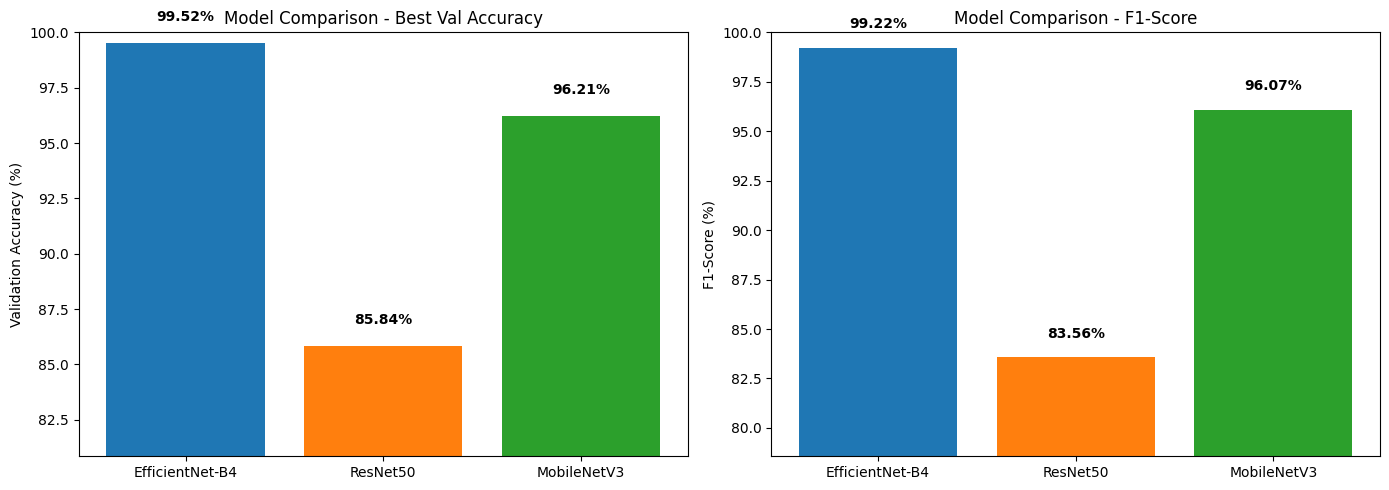


WINNER: EfficientNet-B4 with 99.52% Val Accuracy


In [27]:
import matplotlib.pyplot as plt
import pandas as pd

print("="*60)
print("RESULTS COMPARISON")
print("="*60)

# Táblázat
comparison_data = []
for model_name, results in results_comparison.items():
    metrics = results['final_val_metrics']
    comparison_data.append({
        'Model': model_name,
        'Val Accuracy': f"{results['best_val_acc']:.2f}%",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'AUC': f"{metrics['auc']:.4f}"
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n", df_comparison.to_string(index=False))

# Grafikon
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
accuracies = [results['best_val_acc'] for results in results_comparison.values()]
models = list(results_comparison.keys())

axes[0].bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_title('Model Comparison - Best Val Accuracy')
axes[0].set_ylim([min(accuracies)-5, 100])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')

# F1-Score comparison  
f1_scores = [results['final_val_metrics']['f1']*100 for results in results_comparison.values()]
axes[1].bar(models, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_title('Model Comparison - F1-Score')
axes[1].set_ylim([min(f1_scores)-5, 100])
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Winner
best_model = max(results_comparison.items(), key=lambda x: x[1]['best_val_acc'])
print(f"\nWINNER: {best_model[0]} with {best_model[1]['best_val_acc']:.2f}% Val Accuracy")